访问和读取数据集

In [1]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

In [2]:
def download(name, cache_dir=os.path.join('..', 'data')):  #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [3]:
def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all():  #@save
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

In [4]:
# 如果没有安装pandas，请取消下一行的注释
# !pip install pandas

%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [5]:
DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

In [6]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv下载..\data\kaggle_house_pred_train.csv...
正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv下载..\data\kaggle_house_pred_test.csv...


In [7]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [8]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [9]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

数据预处理

将所有缺失的值替换为相应特征的平均值。通过将特征重新缩放到零均值和单位方差来标准化数据。

In [10]:
# 若无法获得测试数据，则可根据训练数据计算均值和标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
# 在标准化数据之后，所有均值消失，因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

处理离散值，用独热编码替换它们

In [15]:
# “Dummy_na=True”将“na”（缺失值）视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features = all_features.astype('float32')
all_features.shape

(2919, 330)

从pandas格式中提取NumPy格式，并将其转换为张量表示

In [16]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

训练

首先训练一个带有损失平方的线性模型，线性模型将作为基线（baseline）模型， 让我们直观地知道最好的模型有超出简单的模型多少。

In [17]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net

对于房价，我们更关心相对误差$\frac{y - \hat{y}}{y}$


解决这个问题的一种方法是用价格预测的对数来衡量差异

即将$\delta$ for $|\log y - \log \hat{y}| \leq \delta$
转换为$e^{-\delta} \leq \frac{\hat{y}}{y} \leq e^\delta$。
这使得预测价格的对数与真实标签价格的对数之间出现以下均方根误差：

$$\sqrt{\frac{1}{n}\sum_{i=1}^n\left(\log y_i -\log \hat{y}_i\right)^2}.$$


In [19]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

我们的训练函数将借助Adam优化器，对学习率不敏感

In [20]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 这里使用的是Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

K折交叉验证，它有助于模型选择和超参数调整。
我们首先需要定义一个函数，在$K$折交叉验证过程中返回第$i$折的数据。
具体地说，它选择第$i$个切片作为验证数据，其余部分作为训练数据。

In [21]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

在$K$折交叉验证中训练$K$次后，返回训练和验证误差的平均值。

In [22]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

模型选择

折1，训练log rmse0.169709, 验证log rmse0.156460
折2，训练log rmse0.162313, 验证log rmse0.190940
折3，训练log rmse0.163353, 验证log rmse0.168051
折4，训练log rmse0.168436, 验证log rmse0.154676
折5，训练log rmse0.162447, 验证log rmse0.182576
5-折验证: 平均训练log rmse: 0.165251, 平均验证log rmse: 0.170541


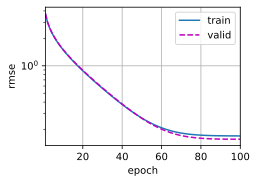

In [23]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

将模型应用于数据集

In [24]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162077


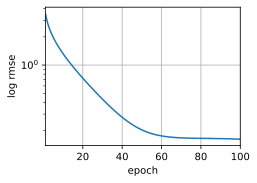

In [25]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

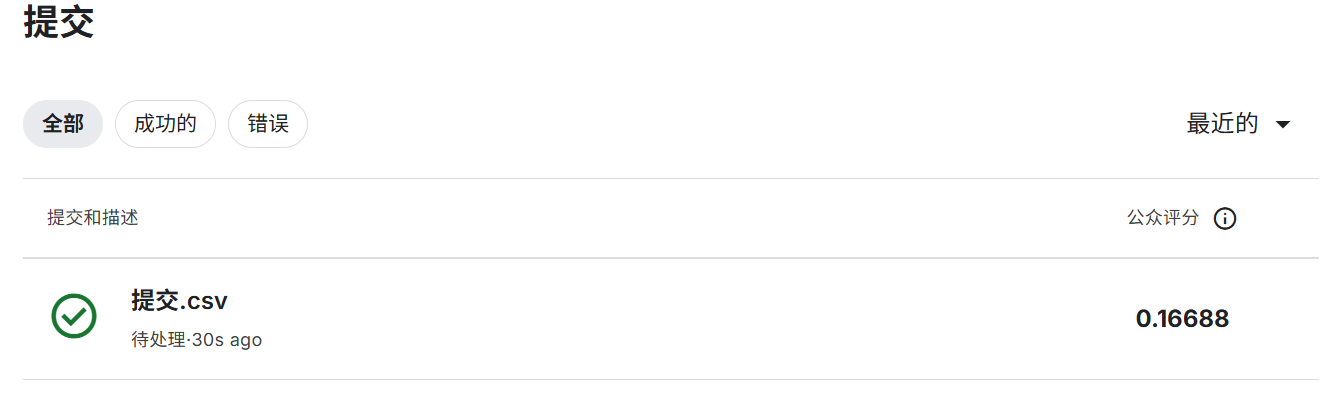

这是讲义所给的示例代码的得分，没有通过K折交叉验证调整超参数，也没有改进模型

折1，训练log rmse0.907986, 验证log rmse0.917627
折2，训练log rmse0.907573, 验证log rmse0.920544
折3，训练log rmse0.906158, 验证log rmse0.922431
折4，训练log rmse0.913794, 验证log rmse0.885887
折5，训练log rmse0.908883, 验证log rmse0.913423
num_epochs=50, lr=1, weight_decay=0, batch_size=32 -> valid log rmse=0.911982
折1，训练log rmse1.500206, 验证log rmse1.512622
折2，训练log rmse1.499630, 验证log rmse1.511445
折3，训练log rmse1.499140, 验证log rmse1.514508
折4，训练log rmse1.507531, 验证log rmse1.482771
折5，训练log rmse1.501657, 验证log rmse1.505388
num_epochs=50, lr=1, weight_decay=0, batch_size=64 -> valid log rmse=1.505347
折1，训练log rmse0.908469, 验证log rmse0.918218
折2，训练log rmse0.907066, 验证log rmse0.920027
折3，训练log rmse0.906701, 验证log rmse0.923043
折4，训练log rmse0.913972, 验证log rmse0.886013
折5，训练log rmse0.909212, 验证log rmse0.913764
num_epochs=50, lr=1, weight_decay=0.01, batch_size=32 -> valid log rmse=0.912213
折1，训练log rmse1.500076, 验证log rmse1.512804
折2，训练log rmse1.499999, 验证log rmse1.511981
折3，训练log rmse1.498767, 验证log rmse1.513662
折4，训练lo

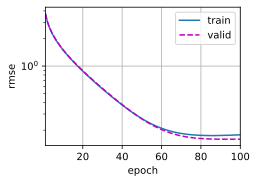

In [27]:
k = 5

num_epochs_list = [50, 100]
lr_list = [1, 3, 5]
weight_decay_list = [0, 0.01, 0.1]
batch_size_list = [32, 64]

best_valid = float('inf')
best_params = None

for num_epochs in num_epochs_list:
    for lr in lr_list:
        for weight_decay in weight_decay_list:
            for batch_size in batch_size_list:
                train_l, valid_l = k_fold(
                    k, train_features, train_labels,
                    num_epochs, lr, weight_decay, batch_size
                )

                print(f'num_epochs={num_epochs}, lr={lr}, '
                      f'weight_decay={weight_decay}, batch_size={batch_size} '
                      f'-> valid log rmse={float(valid_l):.6f}')

                if valid_l < best_valid:
                    best_valid = valid_l
                    best_params = (num_epochs, lr, weight_decay, batch_size)

print('最优参数:', best_params)
print('最优验证误差:', best_valid)

循环测试多组参数，调整超参数，下面将新的模型应用于数据集

训练log rmse：0.139333


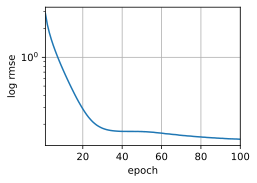

In [28]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 32

def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

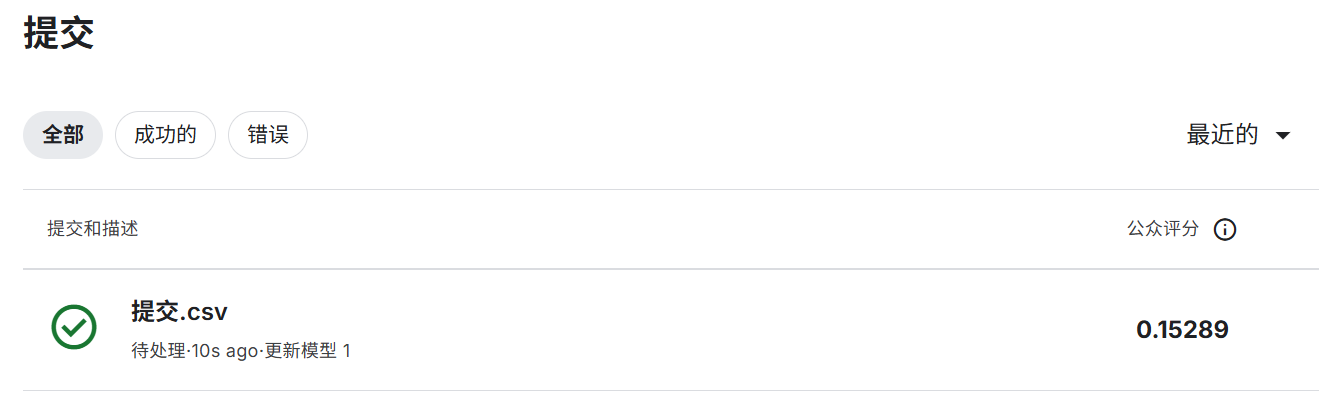
kaggle得分降低，说明改进有效

下面改进模型（例如，层、权重衰减和dropout）来提高分数

新的模型如下，多层感知器，原来是线性回归

In [29]:
def get_net():
    net = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(64, 1)
    )
    return net

新的训练

In [30]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr=learning_rate,
                                 weight_decay=weight_decay)
    loss = nn.MSELoss()

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))

    return train_ls, test_ls

将新模型应用于数据集

折1，训练log rmse0.156942, 验证log rmse0.166366
折2，训练log rmse0.151443, 验证log rmse0.168096
折3，训练log rmse0.154832, 验证log rmse0.162663
折4，训练log rmse0.151753, 验证log rmse0.157292
折5，训练log rmse0.149129, 验证log rmse0.172576
5-折验证: 平均训练log rmse: 0.152820, 平均验证log rmse: 0.165398


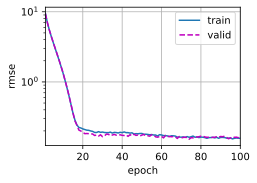

In [35]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.001, 0.01, 32

train_l, valid_l = k_fold(k, train_features, train_labels,
                          num_epochs, lr, weight_decay, batch_size)

print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, 平均验证log rmse: {float(valid_l):f}')

训练log rmse：0.150781


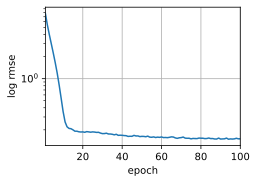

In [38]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

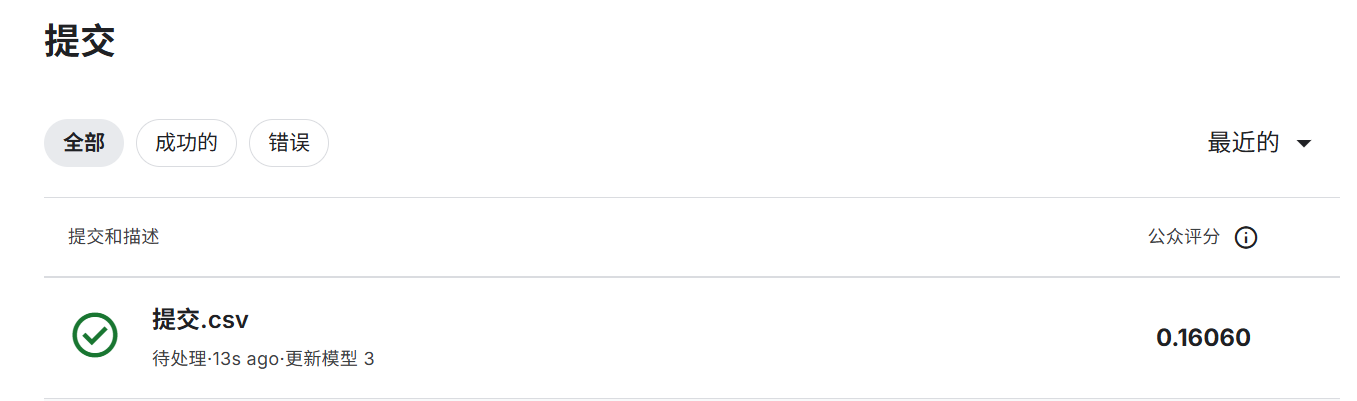
多层感知器的模型的kaggle得分

下面是改进模型的第二个方案，使用轻量级mlp

In [39]:
def get_net():
    net = nn.Sequential(
        nn.Linear(in_features, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )
    return net

折1，训练log rmse2.527600, 验证log rmse2.541369
折2，训练log rmse2.634171, 验证log rmse2.645086
折3，训练log rmse2.633892, 验证log rmse2.649254
折4，训练log rmse2.730234, 验证log rmse2.705483
折5，训练log rmse2.663879, 验证log rmse2.667199
5-折验证: 平均训练log rmse: 2.637955, 平均验证log rmse: 2.641678


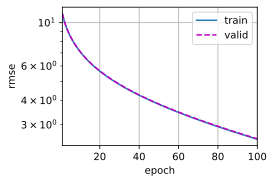

In [40]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.001, 1e-4, 64

train_l, valid_l = k_fold(
    k, train_features, train_labels,
    num_epochs, lr, weight_decay, batch_size
)

print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

训练log rmse：2.476406


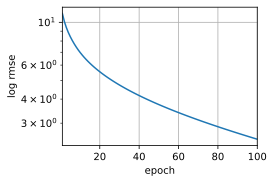

In [41]:
train_and_pred(
    train_features, test_features, train_labels, test_data,
    num_epochs, lr, weight_decay, batch_size
)

可见这个新模型效果很差，说明网络的改进不合适

下面是新的思路，标签取log

In [42]:
train_labels = torch.tensor(
    np.log(train_data.SalePrice.values.reshape(-1,1)),
    dtype=torch.float32
)

In [43]:
def get_net():
    return nn.Sequential(nn.Linear(in_features,1))

折1，训练log rmse0.012105, 验证log rmse0.013730
折2，训练log rmse0.011386, 验证log rmse0.015663
折3，训练log rmse0.011876, 验证log rmse0.014328
折4，训练log rmse0.012188, 验证log rmse0.013213
折5，训练log rmse0.011507, 验证log rmse0.016914
5-折验证: 平均训练log rmse: 0.011813, 平均验证log rmse: 0.014770


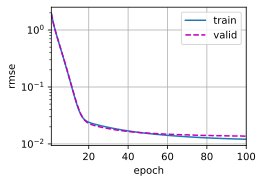

In [44]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.001, 0.01, 32

train_l, valid_l = k_fold(k, train_features, train_labels,
                          num_epochs, lr, weight_decay, batch_size)

print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, 平均验证log rmse: {float(valid_l):f}')

In [45]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')

    # 预测的是 log(price)，所以要 exp 还原
    preds = torch.exp(net(test_features)).detach().numpy()

    test_data['SalePrice'] = pd.Series(preds.reshape(-1))
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.011613


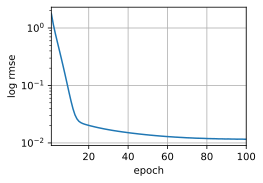

In [46]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

这是使用线性回归模型加log标签的得分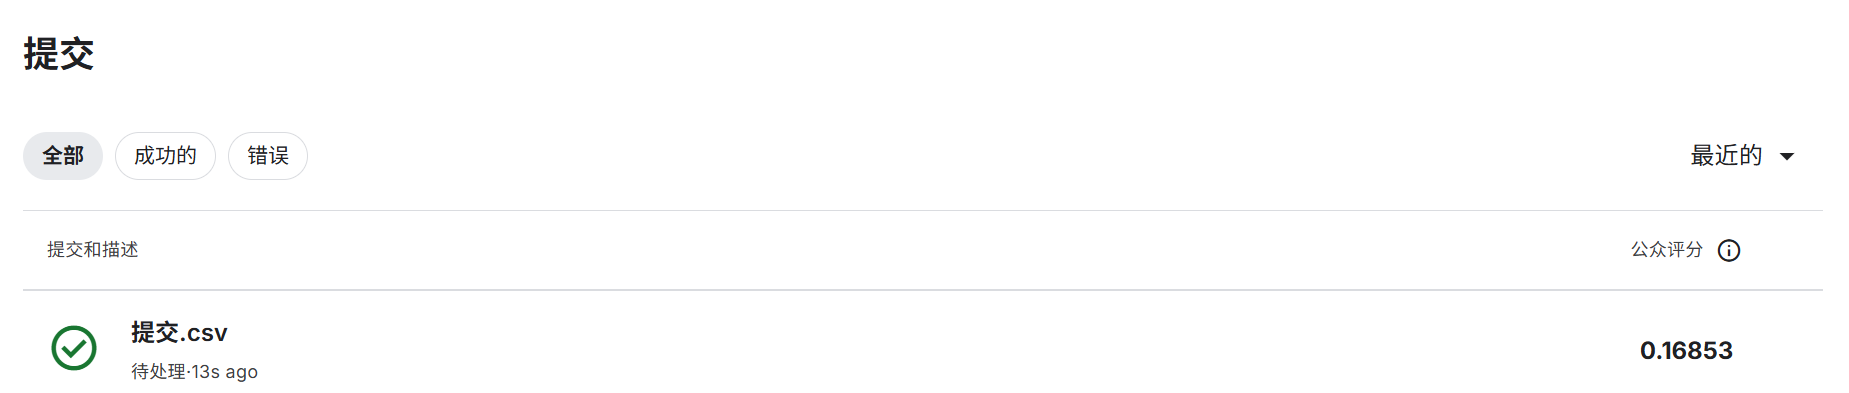

下面进行多层感知器加log标签

In [54]:
def get_net():
    return nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

In [55]:
def log_rmse(net, features, labels):
    preds = net(features)
    rmse = torch.sqrt(nn.MSELoss()(preds, labels))
    return rmse.item()

折1，训练log rmse12.021234, 验证log rmse12.032475
折2，训练log rmse12.044748, 验证log rmse12.050040
折3，训练log rmse11.840793, 验证log rmse11.860063
折4，训练log rmse11.979130, 验证log rmse11.931812
折5，训练log rmse12.087755, 验证log rmse12.096619
5-折验证: 平均训练 rmse(log price): 11.994732, 平均验证 rmse(log price): 11.994202


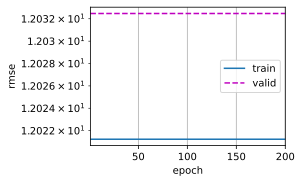

In [56]:
k, num_epochs, lr, weight_decay, batch_size = 5, 200, 0, 1e-4, 64
train_l, valid_l = k_fold(
    k, train_features, train_labels,
    num_epochs, lr, weight_decay, batch_size
)

print(f'{k}-折验证: 平均训练 rmse(log price): {float(train_l):f}, '
      f'平均验证 rmse(log price): {float(valid_l):f}')

训练log rmse：12.125788


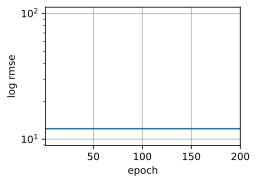

In [57]:
train_and_pred(
    train_features, test_features, train_labels, test_data,
    num_epochs, lr, weight_decay, batch_size
)

可见效果很差

下面不用log标签了，继续修改模型和参数，并且对权重进行初始化，使得网络一开始的参数更平稳

In [58]:
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

In [59]:
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(
        nn.MSELoss()(torch.log(clipped_preds), torch.log(labels))
    )
    return rmse.item()

In [60]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

In [61]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

def get_net():
    net = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Linear(512, 1)
    )
    net.apply(init_weights)
    return net

折1，训练log rmse0.125962, 验证log rmse0.151714
折2，训练log rmse0.121134, 验证log rmse0.154679
折3，训练log rmse0.124092, 验证log rmse0.154874
折4，训练log rmse0.126923, 验证log rmse0.137849
折5，训练log rmse0.117672, 验证log rmse0.162646
5-折验证: 平均训练log rmse: 0.123157, 平均验证log rmse: 0.152352


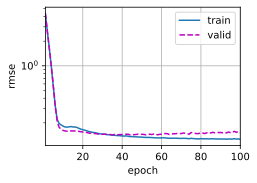

In [62]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.01, 1e-4, 32


train_l, valid_l = k_fold(k, train_features, train_labels,
                          num_epochs, lr, weight_decay, batch_size)

print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, 平均验证log rmse: {float(valid_l):f}')

训练log rmse：0.124198


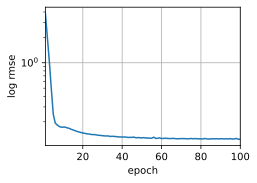

In [63]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)